# ICE Example
This is demo of Individual Conditional Expection (ICE).

# Virtual Environment and Dependencies
Prepare and activate virtual environment with MLI-2 dependencies. Import dependencies:

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from mli.explanation.ice import ICE

## Dataset
Simple dataset with numerical and categorical features:

In [2]:
X = pd.DataFrame({
    'f1': [1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 3],
    'f2': ['cat', 'dog', 'cat9', 'sheep', 'cat5', 'dog4', 'cat1', 'dog',
          'cat1', '1sheep', '2cat', '1dog', '3cat', '2dog', 'cat',
          'sheep5', 'cat', 'dog8'],
    'f3': [50, 40, 30, 20, 10, 0, 55, 45, 35, 25, 15, 3, 50, 40, 30, 20, 10, 0]})

print(X)

    f1      f2  f3
0    1     cat  50
1    2     dog  40
2    3    cat9  30
3    4   sheep  20
4    5    cat5  10
5    6    dog4   0
6    1    cat1  55
7    2     dog  45
8    3    cat1  35
9    4  1sheep  25
10   5    2cat  15
11   6    1dog   3
12   1    3cat  50
13   2    2dog  40
14   3     cat  30
15   4  sheep5  20
16   5     cat  10
17   3    dog8   0


## Regression Examples
Foo predict methods for regression without any dependencies just for demonstration purposes - note method signature with exactly one input parameter (dataset) and Pandas DataFrame return value with 1 column:

In [3]:
# regression predict method returns 1 column
def regression(x):
    return (x['f1']+x['f3'])/100

Compute ICE explanations for feature `f1`, regression predict method and specify **max** and **min**:


'f1':
 'p_0':
    1.000000  1.555556  2.111111  2.666667  3.222222  3.777778  4.333333  \
0       0.51  0.515556  0.521111  0.526667  0.532222  0.537778  0.543333   
1       0.41  0.415556  0.421111  0.426667  0.432222  0.437778  0.443333   
2       0.31  0.315556  0.321111  0.326667  0.332222  0.337778  0.343333   
3       0.21  0.215556  0.221111  0.226667  0.232222  0.237778  0.243333   
4       0.11  0.115556  0.121111  0.126667  0.132222  0.137778  0.143333   
5       0.01  0.015556  0.021111  0.026667  0.032222  0.037778  0.043333   
6       0.56  0.565556  0.571111  0.576667  0.582222  0.587778  0.593333   
7       0.46  0.465556  0.471111  0.476667  0.482222  0.487778  0.493333   
8       0.36  0.365556  0.371111  0.376667  0.382222  0.387778  0.393333   
9       0.26  0.265556  0.271111  0.276667  0.282222  0.287778  0.293333   
10      0.16  0.165556  0.171111  0.176667  0.182222  0.187778  0.193333   
11      0.04  0.045556  0.051111  0.056667  0.062222  0.067778  0.073333 

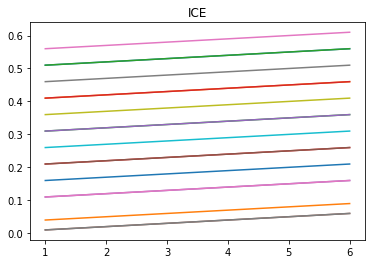

In [4]:
ice = ICE("ICE").explain(['f1'], X, predict_method=regression, mins=[1], maxs=[6])

print(ice)
ice.explanations()['f1']['p_0'].transpose().plot(kind='line', title="ICE", legend=False)
plt.show()

Calculate ICE explanations for given **bins**:

In [5]:
es = ICE("ICE").explain(['f1'], X, predict_method=regression, bins=[[1,3,6]]).explanations()
print(es['f1']['p_0'])

       1     3     6
0   0.51  0.53  0.56
1   0.41  0.43  0.46
2   0.31  0.33  0.36
3   0.21  0.23  0.26
4   0.11  0.13  0.16
5   0.01  0.03  0.06
6   0.56  0.58  0.61
7   0.46  0.48  0.51
8   0.36  0.38  0.41
9   0.26  0.28  0.31
10  0.16  0.18  0.21
11  0.04  0.06  0.09
12  0.51  0.53  0.56
13  0.41  0.43  0.46
14  0.31  0.33  0.36
15  0.21  0.23  0.26
16  0.11  0.13  0.16
17  0.01  0.03  0.06


Calculate and **center** ICE explanations:

In [6]:
ice = ICE("ICE").explain(['f1'], X, predict_method=regression, bins=[[1,3,6]], center=True)
print(ice.explanations()['f1']['p_0'])

           1         3         6
0  -0.023333 -0.003333  0.026667
1  -0.023333 -0.003333  0.026667
2  -0.023333 -0.003333  0.026667
3  -0.023333 -0.003333  0.026667
4  -0.023333 -0.003333  0.026667
5  -0.023333 -0.003333  0.026667
6  -0.023333 -0.003333  0.026667
7  -0.023333 -0.003333  0.026667
8  -0.023333 -0.003333  0.026667
9  -0.023333 -0.003333  0.026667
10 -0.023333 -0.003333  0.026667
11 -0.023333 -0.003333  0.026667
12 -0.023333 -0.003333  0.026667
13 -0.023333 -0.003333  0.026667
14 -0.023333 -0.003333  0.026667
15 -0.023333 -0.003333  0.026667
16 -0.023333 -0.003333  0.026667
17 -0.023333 -0.003333  0.026667


Calculate ICE explanations for **multiple features** and given bins:

In [7]:
ice = ICE("ICE").explain(['f1','f3'], X, predict_method=regression, bins=[[1,2],[5,6,7]])
print(ice)


'f1':
 'p_0':
       1     2
0   0.51  0.52
1   0.41  0.42
2   0.31  0.32
3   0.21  0.22
4   0.11  0.12
5   0.01  0.02
6   0.56  0.57
7   0.46  0.47
8   0.36  0.37
9   0.26  0.27
10  0.16  0.17
11  0.04  0.05
12  0.51  0.52
13  0.41  0.42
14  0.31  0.32
15  0.21  0.22
16  0.11  0.12
17  0.01  0.02
'f3':
 'p_0':
       5     6     7
0   0.06  0.07  0.08
1   0.07  0.08  0.09
2   0.08  0.09  0.10
3   0.09  0.10  0.11
4   0.10  0.11  0.12
5   0.11  0.12  0.13
6   0.06  0.07  0.08
7   0.07  0.08  0.09
8   0.08  0.09  0.10
9   0.09  0.10  0.11
10  0.10  0.11  0.12
11  0.11  0.12  0.13
12  0.06  0.07  0.08
13  0.07  0.08  0.09
14  0.08  0.09  0.10
15  0.09  0.10  0.11
16  0.10  0.11  0.12
17  0.08  0.09  0.10



Calculate ICE explanations for **residuals** and use `average` as transformation function:

In [8]:
ice = ICE("ICE for residuals")

# actual values
Y = pd.DataFrame({'actual values': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.1, 0.2, 0.3, 0.4, 0.5, 0.3]})

ice.explain(['f1'], X, Y=Y, target_transform=abs, predict_method=regression, bins=[[5, 10, 15]])
print(ice.explanations()['f1']['p_0'])

      5     10    15
0   0.45  0.50  0.55
1   0.25  0.30  0.35
2   0.05  0.10  0.15
3   0.15  0.10  0.05
4   0.35  0.30  0.25
5   0.55  0.50  0.45
6   0.50  0.55  0.60
7   0.30  0.35  0.40
8   0.10  0.15  0.20
9   0.10  0.05  0.00
10  0.30  0.25  0.20
11  0.52  0.47  0.42
12  0.45  0.50  0.55
13  0.25  0.30  0.35
14  0.05  0.10  0.15
15  0.15  0.10  0.05
16  0.35  0.30  0.25
17  0.25  0.20  0.15


Calculate **out of range** ICE for 2x standard deviations (below and above):

In [9]:
ice = ICE("Out of range ICE")
ice.explain(
    ['f1'], 
    X, 
    bins=[[2, 4]],
    predict_method=regression, 
    out_of_range_resolution=2, mins=[1], maxs=[6], stds=[1.6449566416599])

print(ice)


'f1':
 'p_0':
     2.000000   4.000000  -0.644957  -2.289913   7.644957   9.289913
0        0.52       0.54    0.49355   0.477101    0.57645   0.592899
1        0.42       0.44    0.39355   0.377101    0.47645   0.492899
2        0.32       0.34    0.29355   0.277101    0.37645   0.392899
3        0.22       0.24    0.19355   0.177101    0.27645   0.292899
4        0.12       0.14    0.09355   0.077101    0.17645   0.192899
5        0.02       0.04   -0.00645  -0.022899    0.07645   0.092899
6        0.57       0.59    0.54355   0.527101    0.62645   0.642899
7        0.47       0.49    0.44355   0.427101    0.52645   0.542899
8        0.37       0.39    0.34355   0.327101    0.42645   0.442899
9        0.27       0.29    0.24355   0.227101    0.32645   0.342899
10       0.17       0.19    0.14355   0.127101    0.22645   0.242899
11       0.05       0.07    0.02355   0.007101    0.10645   0.122899
12       0.52       0.54    0.49355   0.477101    0.57645   0.592899
13       0.42      

Calculate ICE and specify **how many** bins should be created using `grid_resolution` parameter:

In [10]:
ice = ICE("ICE").explain(['f1'], X, predict_method=regression, mins=[1], maxs=[6], grid_resolution=6)
print(ice)


'f1':
 'p_0':
     1.0   2.0   3.0   4.0   5.0   6.0
0   0.51  0.52  0.53  0.54  0.55  0.56
1   0.41  0.42  0.43  0.44  0.45  0.46
2   0.31  0.32  0.33  0.34  0.35  0.36
3   0.21  0.22  0.23  0.24  0.25  0.26
4   0.11  0.12  0.13  0.14  0.15  0.16
5   0.01  0.02  0.03  0.04  0.05  0.06
6   0.56  0.57  0.58  0.59  0.60  0.61
7   0.46  0.47  0.48  0.49  0.50  0.51
8   0.36  0.37  0.38  0.39  0.40  0.41
9   0.26  0.27  0.28  0.29  0.30  0.31
10  0.16  0.17  0.18  0.19  0.20  0.21
11  0.04  0.05  0.06  0.07  0.08  0.09
12  0.51  0.52  0.53  0.54  0.55  0.56
13  0.41  0.42  0.43  0.44  0.45  0.46
14  0.31  0.32  0.33  0.34  0.35  0.36
15  0.21  0.22  0.23  0.24  0.25  0.26
16  0.11  0.12  0.13  0.14  0.15  0.16
17  0.01  0.02  0.03  0.04  0.05  0.06



Calculate ICE for **categorical** feature:

In [11]:
ice = ICE("Cat feature ICE").explain(['f2'], X, predict_method=regression, bins=[['cat','dog','sheep']])
print(ice)


'f2':
 'p_0':
     cat   dog  sheep
0   0.51  0.51   0.51
1   0.42  0.42   0.42
2   0.33  0.33   0.33
3   0.24  0.24   0.24
4   0.15  0.15   0.15
5   0.06  0.06   0.06
6   0.56  0.56   0.56
7   0.47  0.47   0.47
8   0.38  0.38   0.38
9   0.29  0.29   0.29
10  0.20  0.20   0.20
11  0.09  0.09   0.09
12  0.51  0.51   0.51
13  0.42  0.42   0.42
14  0.33  0.33   0.33
15  0.24  0.24   0.24
16  0.15  0.15   0.15
17  0.03  0.03   0.03



**Indicate** that feature is categorical (regardless there are numerical values) - note that values are ordered by **frequency**:

In [12]:
ice = ICE('Cat ICE')
ice.explain(
    ['f1'], 
    X, 
    predict_method=regression, 
    mins=[1], 
    maxs=[6], 
    features_meta = {'categorical': ['f1']})
print(ice.explanations()['f1']['p_0'])

       3     5     4     2     1     6
0   0.53  0.55  0.54  0.52  0.51  0.56
1   0.43  0.45  0.44  0.42  0.41  0.46
2   0.33  0.35  0.34  0.32  0.31  0.36
3   0.23  0.25  0.24  0.22  0.21  0.26
4   0.13  0.15  0.14  0.12  0.11  0.16
5   0.03  0.05  0.04  0.02  0.01  0.06
6   0.58  0.60  0.59  0.57  0.56  0.61
7   0.48  0.50  0.49  0.47  0.46  0.51
8   0.38  0.40  0.39  0.37  0.36  0.41
9   0.28  0.30  0.29  0.27  0.26  0.31
10  0.18  0.20  0.19  0.17  0.16  0.21
11  0.06  0.08  0.07  0.05  0.04  0.09
12  0.53  0.55  0.54  0.52  0.51  0.56
13  0.43  0.45  0.44  0.42  0.41  0.46
14  0.33  0.35  0.34  0.32  0.31  0.36
15  0.23  0.25  0.24  0.22  0.21  0.26
16  0.13  0.15  0.14  0.12  0.11  0.16
17  0.03  0.05  0.04  0.02  0.01  0.06


# Multinomial Classification Examples
Foo predict method for multinomial classification without any dependencies just for demonstration purposes - note method signature with exactly one input parameter (dataset) and Pandas DataFrame return value with more than 2 columns:

In [13]:
# multinomial classification predict method returns >2 columns
def multiclass(x):
    c1 = (X['f1']+X['f3'])/100
    c2 = abs((X['f1']-X['f3'])/100)
    c3 = 1-(c1+c2)
    return pd.DataFrame({'c1':c1, 'c2':c2, 'c3':c3})

Compute ICE explanations for feature f1, multiclass predict method and specify max and min:


'f1':
 'p_0':
    1.000000  1.555556  2.111111  2.666667  3.222222  3.777778  4.333333  \
0       0.51  0.515556  0.521111  0.526667  0.532222  0.537778  0.543333   
1       0.41  0.415556  0.421111  0.426667  0.432222  0.437778  0.443333   
2       0.31  0.315556  0.321111  0.326667  0.332222  0.337778  0.343333   
3       0.21  0.215556  0.221111  0.226667  0.232222  0.237778  0.243333   
4       0.11  0.115556  0.121111  0.126667  0.132222  0.137778  0.143333   
5       0.01  0.015556  0.021111  0.026667  0.032222  0.037778  0.043333   
6       0.56  0.565556  0.571111  0.576667  0.582222  0.587778  0.593333   
7       0.46  0.465556  0.471111  0.476667  0.482222  0.487778  0.493333   
8       0.36  0.365556  0.371111  0.376667  0.382222  0.387778  0.393333   
9       0.26  0.265556  0.271111  0.276667  0.282222  0.287778  0.293333   
10      0.16  0.165556  0.171111  0.176667  0.182222  0.187778  0.193333   
11      0.04  0.045556  0.051111  0.056667  0.062222  0.067778  0.073333 

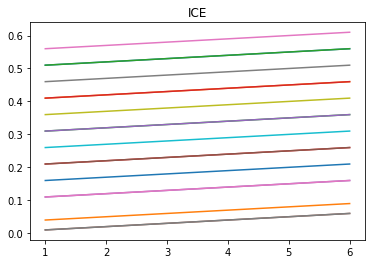

In [14]:
ice = ICE("ICE").explain(['f1'], X, predict_method=multiclass, mins=[1], maxs=[6])

print(ice)
ice.explanations()['f1']['p_0'].transpose().plot(kind='line', title="ICE", legend=False)
plt.show()

# Multi-dimensional ICE examples

Calculate **multi-dimensional** ICE for multiple features.

In [15]:
ice = ICE("m-ICE").explain([('f1','f2'),'f1'], X, predict_method=regression, bins=[([1,2],[3,4,5]),[7,8]])

print(ice)


'('f1', 'f2')':
 'p_0':
    (1, 3)  (1, 4)  (1, 5)  (2, 3)  (2, 4)  (2, 5)
0     0.51    0.51    0.51    0.52    0.52    0.52
1     0.41    0.41    0.41    0.42    0.42    0.42
2     0.31    0.31    0.31    0.32    0.32    0.32
3     0.21    0.21    0.21    0.22    0.22    0.22
4     0.11    0.11    0.11    0.12    0.12    0.12
5     0.01    0.01    0.01    0.02    0.02    0.02
6     0.56    0.56    0.56    0.57    0.57    0.57
7     0.46    0.46    0.46    0.47    0.47    0.47
8     0.36    0.36    0.36    0.37    0.37    0.37
9     0.26    0.26    0.26    0.27    0.27    0.27
10    0.16    0.16    0.16    0.17    0.17    0.17
11    0.04    0.04    0.04    0.05    0.05    0.05
12    0.51    0.51    0.51    0.52    0.52    0.52
13    0.41    0.41    0.41    0.42    0.42    0.42
14    0.31    0.31    0.31    0.32    0.32    0.32
15    0.21    0.21    0.21    0.22    0.22    0.22
16    0.11    0.11    0.11    0.12    0.12    0.12
17    0.01    0.01    0.01    0.02    0.02    0.02
'f1':


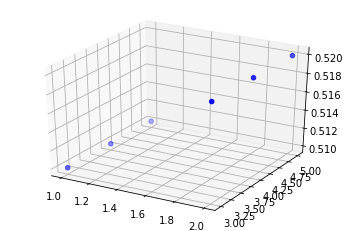

In [16]:
x = []
y = []
z = []
df = ice.explanations()[('f1','f2')]['p_0']
for c in df.columns.values:
    x.append(c[0])
    y.append(c[1])
    z.append(df.iloc[0][c])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='b', marker='o')
plt.show()